## GPU Environment Verification

This cell verifies that the notebook is using the GPU-lab virtual environment and detects the available NVIDIA GPU. Full Task 1 training should only begin after CUDA is confirmed.

In [1]:
import sys
import torch

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / (1024 ** 3),
            2
        ),
        "GB"
    )
else:
    print("CUDA is not available. Do not start final training yet.")

Python executable: c:\Users\prerana\Documents\DATA266_Lab1\.venv\Scripts\python.exe
PyTorch version: 2.14.0+cu130
CUDA available: True
GPU name: NVIDIA GeForce RTX 4090
GPU memory: 23.99 GB


In [2]:
import sys

print(sys.executable)

c:\Users\prerana\Documents\DATA266_Lab1\.venv\Scripts\python.exe


In [3]:
from pathlib import Path
import os
import yaml

# Locate DATA266_Lab1 from the notebook location
CURRENT_PATH = Path.cwd().resolve()

project_candidates = [
    path for path in [CURRENT_PATH, *CURRENT_PATH.parents]
    if path.name == "DATA266_Lab1" and path.is_dir()
]

if project_candidates:
    PROJECT_ROOT = project_candidates[0]
else:
    raise FileNotFoundError(
        "Could not locate the DATA266_Lab1 project folder."
    )

# Load config.yaml
CONFIG_PATH = PROJECT_ROOT / "task1_llm" / "config.yaml"

if not CONFIG_PATH.exists():
    CONFIG_PATH = (
        PROJECT_ROOT
        / "task1_llm"
        / "Vrishin"
        / "config.yaml"
    )

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        "config.yaml was not found in task1_llm "
        "or task1_llm/Vrishin."
    )

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    CONFIG = yaml.safe_load(file)

# Configure project folders from config.yaml
TASK_ROOT = PROJECT_ROOT / CONFIG["paths"]["member_dir"]
SRC_DIR = TASK_ROOT / "src"
CHECKPOINT_DIR = PROJECT_ROOT / CONFIG["paths"]["checkpoints_dir"]
OUTPUT_DIR = PROJECT_ROOT / CONFIG["paths"]["outputs_dir"]
DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["processed_dir"]
LOG_DIR = PROJECT_ROOT / CONFIG["paths"]["logs_dir"]
SHARED_DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["shared_data_dir"]

for folder in [
    SRC_DIR,
    CHECKPOINT_DIR,
    OUTPUT_DIR,
    DATA_DIR,
    LOG_DIR,
    SHARED_DATA_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Keep Hugging Face cache outside the project repository
HF_CACHE_DIR = Path(
    os.environ.get("LOCALAPPDATA", str(PROJECT_ROOT))
) / "DATA266_Lab1_hf_cache"

HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["HF_HUB_CACHE"] = str(HF_CACHE_DIR / "hub")
os.environ["HF_DATASETS_CACHE"] = str(HF_CACHE_DIR / "datasets")
os.environ["HUGGINGFACE_HUB_CACHE"] = str(HF_CACHE_DIR / "hub")

print("Project folders configured.")
print("Configuration loaded.")
print("Task member folder: task1_llm/Vrishin")
print("Hugging Face cache: outside the project repository")

Project folders configured.
Configuration loaded.
Task member folder: task1_llm/Vrishin
Hugging Face cache: outside the project repository


In [4]:
# Load configuration and initialize the reproducible GPU environment

import os
import sys
import json
import time
import random
import platform
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Locate the DATA266_Lab1 project root without hard-coded personal paths
CURRENT_PATH = Path.cwd().resolve()

project_candidates = [
    path for path in [CURRENT_PATH, *CURRENT_PATH.parents]
    if path.name == "DATA266_Lab1" and path.is_dir()
]

if project_candidates:
    PROJECT_ROOT = project_candidates[0]
elif (CURRENT_PATH / "DATA266_Lab1").is_dir():
    PROJECT_ROOT = CURRENT_PATH / "DATA266_Lab1"
else:
    raise FileNotFoundError(
        "Could not locate the DATA266_Lab1 project folder."
    )

# Load all settings from config.yaml
CONFIG_PATH = PROJECT_ROOT / "task1_llm" / "config.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    CONFIG = yaml.safe_load(file)

SEED = int(CONFIG["seed"])

# Configure paths from config.yaml
SHARED_DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["shared_data_dir"]
TASK_ROOT = PROJECT_ROOT / CONFIG["paths"]["member_dir"]
CHECKPOINT_DIR = PROJECT_ROOT / CONFIG["paths"]["checkpoints_dir"]
OUTPUT_DIR = PROJECT_ROOT / CONFIG["paths"]["outputs_dir"]
DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["processed_dir"]
LOG_DIR = PROJECT_ROOT / CONFIG["paths"]["logs_dir"]

for folder in [
    SHARED_DATA_DIR,
    TASK_ROOT,
    CHECKPOINT_DIR,
    OUTPUT_DIR,
    DATA_DIR,
    LOG_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Keep Hugging Face cache outside the repository
HF_CACHE_DIR = Path(
    os.environ.get("LOCALAPPDATA", str(PROJECT_ROOT))
) / "DATA266_Lab1_hf_cache"

HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["HF_HUB_CACHE"] = str(HF_CACHE_DIR / "hub")
os.environ["HF_DATASETS_CACHE"] = str(HF_CACHE_DIR / "datasets")
os.environ["HUGGINGFACE_HUB_CACHE"] = str(HF_CACHE_DIR / "hub")

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
CONFIG_PATH = PROJECT_ROOT / "task1_llm" / "config.yaml"
print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed: 8844
PyTorch: 2.14.0+cu130
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4090


## Final GPU Training Configuration

This configuration uses the required TinyStories split and trains the 4-layer GPT model for at least 10 epochs.

The local smoke-test settings are replaced by these GPU settings for the final Task 1 run.

In [5]:
# Build the Task 1 configuration from config.yaml

TASK1_CONFIG = {
    "seed": SEED,
    "context_length": int(
        CONFIG["dataset"]["context_length"]
    ),
    "batch_size": int(
        CONFIG["training"]["batch_size"]
    ),
    "embedding_dim": int(
        CONFIG["model"]["embedding_dim"]
    ),
    "num_heads": int(
        CONFIG["model"]["num_heads"]
    ),
    "num_layers": int(
        CONFIG["model"]["num_layers"]
    ),
    "dropout": float(
        CONFIG["model"]["dropout"]
    ),
    "learning_rate": float(
        CONFIG["training"]["learning_rate"]
    ),
    "epochs": int(
        CONFIG["training"]["epochs"]
    ),
    "train_sequences": int(
        CONFIG["dataset"]["train_sequences"]
    ),
    "validation_sequences": int(
        CONFIG["dataset"]["validation_sequences"]
    ),
    "weight_decay": float(
        CONFIG["training"]["weight_decay"]
    ),
    "warmup_fraction": float(
        CONFIG["training"]["warmup_fraction"]
    ),
    "gradient_clip_norm": float(
        CONFIG["training"]["gradient_clip_norm"]
    ),
}

print("Configuration loaded from config.yaml:")
for key, value in TASK1_CONFIG.items():
    print(f"{key}: {value}")

Configuration loaded from config.yaml:
seed: 8844
context_length: 128
batch_size: 64
embedding_dim: 256
num_heads: 4
num_layers: 4
dropout: 0.1
learning_rate: 0.0003
epochs: 10
train_sequences: 100000
validation_sequences: 10000
weight_decay: 0.01
warmup_fraction: 0.05
gradient_clip_norm: 1.0


In [6]:
from pathlib import Path
import json

CURRENT_PATH = Path.cwd().resolve()

# Find DATA266_Lab1 either as the current folder, a parent folder,
# or a child folder of the current working directory.
possible_roots = [
    path for path in [CURRENT_PATH, *CURRENT_PATH.parents]
    if path.name == "DATA266_Lab1" and path.is_dir()
]

if possible_roots:
    PROJECT_ROOT = possible_roots[0]
elif (CURRENT_PATH / "DATA266_Lab1").is_dir():
    PROJECT_ROOT = CURRENT_PATH / "DATA266_Lab1"
else:
    raise FileNotFoundError(
        "Could not locate the DATA266_Lab1 project folder."
    )

TASK_ROOT = PROJECT_ROOT / "task1_llm" / "Vrishin"

SRC_DIR = TASK_ROOT / "src"
CHECKPOINT_DIR = TASK_ROOT / "checkpoints"
OUTPUT_DIR = TASK_ROOT / "outputs"
DATA_DIR = TASK_ROOT / "data_processed"

for folder in [SRC_DIR, CHECKPOINT_DIR, OUTPUT_DIR, DATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "task1_final_config.json", "w") as f:
    json.dump(TASK1_CONFIG, f, indent=2)


print("Folders created successfully.")

Correct project root: C:\Users\prerana\Documents\DATA266_Lab1
Correct task folder: C:\Users\prerana\Documents\DATA266_Lab1\task1_llm\Vrishin
Folders created successfully.


In [7]:
# Load or create the shared raw TinyStories files
# Then create a reproducible per-member story selection.

from datasets import load_dataset
import json
import random

RAW_TRAIN_PATH = SHARED_DATA_DIR / "train_stories.json"
RAW_VALIDATION_PATH = SHARED_DATA_DIR / "validation_stories.json"

PROCESSED_TRAIN_PATH = DATA_DIR / "member_train_stories.json"
PROCESSED_VALIDATION_PATH = DATA_DIR / "member_validation_stories.json"
SPLIT_METADATA_PATH = DATA_DIR / "member_split_metadata.json"


def save_dataset_as_jsonl(dataset, output_path):
    """Save one JSON story record per line."""
    with output_path.open("w", encoding="utf-8") as file:
        for record in dataset:
            json.dump(record, file, ensure_ascii=False)
            file.write("\n")


def count_jsonl_records(file_path):
    """Count records without loading the entire file into memory."""
    with file_path.open("r", encoding="utf-8") as file:
        return sum(1 for _ in file)


def load_jsonl_records(file_path):
    """Load JSONL records into a list."""
    records = []

    with file_path.open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


def select_seeded_stories(
    input_path,
    output_path,
    number_of_stories,
    rng,
    split_name
):
    """Select stories using a seeded random selection."""

    total_records = count_jsonl_records(input_path)

    if total_records < number_of_stories:
        raise ValueError(
            f"{split_name} contains only {total_records} stories, "
            f"but {number_of_stories} are required."
        )

    selected_indices = set(
        rng.sample(
            range(total_records),
            number_of_stories
        )
    )

    selected_records = []

    with input_path.open("r", encoding="utf-8") as source_file:
        for index, line in enumerate(source_file):
            if index in selected_indices:
                record = json.loads(line)
                selected_records.append(record)

    with output_path.open("w", encoding="utf-8") as output_file:
        for record in selected_records:
            json.dump(
                record,
                output_file,
                ensure_ascii=False
            )
            output_file.write("\n")

    return selected_records


# Download and save the raw dataset only if the shared raw files do not exist.
if not RAW_TRAIN_PATH.exists():
    print("Raw training file not found.")
    print("Downloading the complete TinyStories training split...")

    full_train_dataset = load_dataset(
        CONFIG["dataset"]["name"],
        split="train",
        cache_dir=str(HF_CACHE_DIR / "datasets")
    )

    save_dataset_as_jsonl(
        full_train_dataset,
        RAW_TRAIN_PATH
    )

    print("Raw training data saved.")

if not RAW_VALIDATION_PATH.exists():
    print("Raw validation file not found.")
    print("Downloading the complete TinyStories validation split...")

    full_validation_dataset = load_dataset(
        CONFIG["dataset"]["name"],
        split="validation",
        cache_dir=str(HF_CACHE_DIR / "datasets")
    )

    save_dataset_as_jsonl(
        full_validation_dataset,
        RAW_VALIDATION_PATH
    )

    print("Raw validation data saved.")


# Use one seeded random generator for this member's selection.
# This differs from teammates using different seeds.
split_rng = random.Random(SEED)

train_records = select_seeded_stories(
    input_path=RAW_TRAIN_PATH,
    output_path=PROCESSED_TRAIN_PATH,
    number_of_stories=TASK1_CONFIG["train_sequences"],
    rng=split_rng,
    split_name="training data"
)

validation_records = select_seeded_stories(
    input_path=RAW_VALIDATION_PATH,
    output_path=PROCESSED_VALIDATION_PATH,
    number_of_stories=TASK1_CONFIG["validation_sequences"],
    rng=split_rng,
    split_name="validation data"
)

train_texts = [
    record["text"]
    for record in train_records
    if isinstance(record.get("text"), str)
]

validation_texts = [
    record["text"]
    for record in validation_records
    if isinstance(record.get("text"), str)
]

split_metadata = {
    "seed": SEED,
    "dataset": CONFIG["dataset"]["name"],
    "train_stories_selected": len(train_texts),
    "validation_stories_selected": len(validation_texts),
    "train_sequences_required": TASK1_CONFIG["train_sequences"],
    "validation_sequences_required": (
        TASK1_CONFIG["validation_sequences"]
    ),
    "context_length": TASK1_CONFIG["context_length"],
    "selection_method": (
        "random.Random(SEED) over the complete raw story files"
    ),
    "raw_data_format": "JSONL records stored in .json files"
}

with SPLIT_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(split_metadata, file, indent=2)

print("Per-member seeded split created.")
print("Training stories selected:", len(train_texts))
print("Validation stories selected:", len(validation_texts))
print("Processed split saved in: task1_llm/Vrishin/data_processed/")

Per-member seeded split created.
Training stories selected: 100000
Validation stories selected: 10000
Processed split saved in: task1_llm/Vrishin/data_processed/


In [8]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("TASK_ROOT:", TASK_ROOT)
print("DATA_DIR exists:", DATA_DIR.exists())
print("CHECKPOINT_DIR exists:", CHECKPOINT_DIR.exists())
print("OUTPUT_DIR exists:", OUTPUT_DIR.exists())

PROJECT_ROOT: C:\Users\prerana\Documents\DATA266_Lab1
TASK_ROOT: C:\Users\prerana\Documents\DATA266_Lab1\task1_llm\Vrishin
DATA_DIR exists: True
CHECKPOINT_DIR exists: True
OUTPUT_DIR exists: True


In [9]:
# Build the character vocabulary from TRAIN data only.
# Validation characters not seen during training are mapped explicitly
# to <UNK> instead of being silently removed.

UNK_TOKEN = "<UNK>"

train_text_for_vocabulary = "\n".join(train_texts)

train_characters = sorted(
    set(train_text_for_vocabulary)
)

vocabulary = [
    UNK_TOKEN
] + train_characters

char_to_idx = {
    character: index
    for index, character in enumerate(vocabulary)
}

idx_to_char = {
    index: character
    for character, index in char_to_idx.items()
}

vocab_size = len(vocabulary)
unk_index = char_to_idx[UNK_TOKEN]


def encode(text):
    """Encode text and count characters unknown to the vocabulary."""

    encoded_values = []
    unknown_count = 0

    for character in text:
        if character in char_to_idx:
            encoded_values.append(char_to_idx[character])
        else:
            encoded_values.append(unk_index)
            unknown_count += 1

    return encoded_values, unknown_count


def decode(indices):
    """Decode token IDs back into characters or <UNK>."""

    return "".join(
        idx_to_char.get(index, UNK_TOKEN)
        for index in indices
    )


encoded_train_text, train_unknown_count = encode(
    "\n".join(train_texts)
)

encoded_validation_text, validation_unknown_count = encode(
    "\n".join(validation_texts)
)

print("Vocabulary built from training data only.")
print("Vocabulary size:", vocab_size)
print("Training characters:", len(encoded_train_text))
print("Validation characters:", len(encoded_validation_text))
print("Unknown training characters:", train_unknown_count)
print("Unknown validation characters:", validation_unknown_count)

print("\nVocabulary examples:")
for index in range(min(10, vocab_size)):
    print(repr(idx_to_char[index]), "->", index)

print("\nDecoded training sample:")
print(decode(encoded_train_text[:100]))

Vocabulary built from training data only.
Vocabulary size: 110
Training characters: 89720458
Validation characters: 8730491
Unknown training characters: 0
Unknown validation characters: 4

Vocabulary examples:
'<UNK>' -> 0
'\n' -> 1
' ' -> 2
'!' -> 3
'"' -> 4
'$' -> 5
'%' -> 6
'&' -> 7
"'" -> 8
'(' -> 9

Decoded training sample:
Once upon a time, there was a boy named Tom. He loved gum. One day, he found a thin piece of gum on 


In [10]:
from torch.utils.data import TensorDataset, DataLoader

# 100K/10K means exactly:
# - 100,000 training examples
# - 10,000 validation examples
# - each example has 128 input characters
# - each target is shifted by one character
# Therefore, each example uses 129 encoded characters total.

def create_sequences(
    encoded_text,
    number_of_sequences,
    context_length
):
    required_length = number_of_sequences * (
        context_length + 1
    )

    if len(encoded_text) < required_length:
        raise ValueError(
            f"Not enough encoded characters. "
            f"Required: {required_length}; "
            f"available: {len(encoded_text)}."
        )

    data = torch.tensor(
        encoded_text[:required_length],
        dtype=torch.long
    )

    data = data.view(
        number_of_sequences,
        context_length + 1
    )

    inputs = data[:, :-1]
    targets = data[:, 1:]

    if inputs.shape != (
        number_of_sequences,
        context_length
    ):
        raise RuntimeError(
            f"Unexpected input shape: {inputs.shape}"
        )

    if targets.shape != (
        number_of_sequences,
        context_length
    ):
        raise RuntimeError(
            f"Unexpected target shape: {targets.shape}"
        )

    return inputs, targets


X_train, y_train = create_sequences(
    encoded_train_text,
    TASK1_CONFIG["train_sequences"],
    TASK1_CONFIG["context_length"]
)

X_validation, y_validation = create_sequences(
    encoded_validation_text,
    TASK1_CONFIG["validation_sequences"],
    TASK1_CONFIG["context_length"]
)

train_dataset = TensorDataset(
    X_train,
    y_train
)

validation_dataset = TensorDataset(
    X_validation,
    y_validation
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TASK1_CONFIG["batch_size"],
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=TASK1_CONFIG["batch_size"],
    shuffle=False
)

print("Training input shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("Validation input shape:", X_validation.shape)
print("Validation target shape:", y_validation.shape)

Training input shape: torch.Size([100000, 128])
Training target shape: torch.Size([100000, 128])
Validation input shape: torch.Size([10000, 128])
Validation target shape: torch.Size([10000, 128])


In [11]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads, context_length, dropout):
        super().__init__()

        if embedding_dim % num_heads != 0:
            raise ValueError("embedding_dim must be divisible by num_heads")

        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads

        self.qkv = nn.Linear(embedding_dim, 3 * embedding_dim)
        self.output_projection = nn.Linear(embedding_dim, embedding_dim)

        self.attention_dropout = nn.Dropout(dropout)
        self.residual_dropout = nn.Dropout(dropout)

        causal_mask = torch.tril(
            torch.ones(context_length, context_length)
        ).bool()

        self.register_buffer(
            "causal_mask",
            causal_mask.view(1, 1, context_length, context_length)
        )

    def forward(self, x):
        batch_size, sequence_length, embedding_dim = x.shape

        qkv = self.qkv(x)

        qkv = qkv.view(
            batch_size,
            sequence_length,
            3,
            self.num_heads,
            self.head_dim
        )

        qkv = qkv.permute(2, 0, 3, 1, 4)

        query, key, value = qkv[0], qkv[1], qkv[2]

        attention_scores = query @ key.transpose(-2, -1)
        attention_scores = attention_scores / (self.head_dim ** 0.5)

        current_mask = self.causal_mask[
            :, :, :sequence_length, :sequence_length
        ]

        attention_scores = attention_scores.masked_fill(
            ~current_mask,
            float("-inf")
        )

        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )

        attention_weights = self.attention_dropout(attention_weights)

        attention_output = attention_weights @ value

        attention_output = attention_output.transpose(1, 2).contiguous()

        attention_output = attention_output.view(
            batch_size,
            sequence_length,
            embedding_dim
        )

        output = self.output_projection(attention_output)
        output = self.residual_dropout(output)

        return output


class FeedForwardNetwork(nn.Module):
    def __init__(self, embedding_dim, dropout):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.GELU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.network(x)


class TransformerBlock(nn.Module):
    def __init__(
        self,
        embedding_dim,
        num_heads,
        context_length,
        dropout
    ):
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embedding_dim)
        self.attention = MultiHeadSelfAttention(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            context_length=context_length,
            dropout=dropout
        )

        self.layer_norm_2 = nn.LayerNorm(embedding_dim)
        self.feed_forward = FeedForwardNetwork(
            embedding_dim=embedding_dim,
            dropout=dropout
        )

    def forward(self, x):
        x = x + self.attention(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))

        return x


class GPTLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_heads,
        num_layers,
        context_length,
        dropout
    ):
        super().__init__()

        self.context_length = context_length

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.position_embedding = nn.Embedding(
            context_length,
            embedding_dim
        )

        self.dropout = nn.Dropout(dropout)

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                embedding_dim=embedding_dim,
                num_heads=num_heads,
                context_length=context_length,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.final_layer_norm = nn.LayerNorm(embedding_dim)

        self.language_model_head = nn.Linear(
            embedding_dim,
            vocab_size,
            bias=False
        )

    def forward(self, input_ids, targets=None):
        batch_size, sequence_length = input_ids.shape

        if sequence_length > self.context_length:
            raise ValueError(
                "Input sequence is longer than the model context length."
            )

        positions = torch.arange(
            sequence_length,
            device=input_ids.device
        )

        token_embeddings = self.token_embedding(input_ids)
        position_embeddings = self.position_embedding(positions)

        x = token_embeddings + position_embeddings
        x = self.dropout(x)

        for block in self.transformer_blocks:
            x = block(x)

        x = self.final_layer_norm(x)

        logits = self.language_model_head(x)

        loss = None

        if targets is not None:
            batch_size, sequence_length, vocab_size = logits.shape

            logits_for_loss = logits.view(
                batch_size * sequence_length,
                vocab_size
            )

            targets_for_loss = targets.view(
                batch_size * sequence_length
            )

            loss = F.cross_entropy(
                logits_for_loss,
                targets_for_loss
            )

        return logits, loss

In [12]:
model = GPTLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=TASK1_CONFIG["embedding_dim"],
    num_heads=TASK1_CONFIG["num_heads"],
    num_layers=TASK1_CONFIG["num_layers"],
    context_length=TASK1_CONFIG["context_length"],
    dropout=TASK1_CONFIG["dropout"]
).to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

sample_inputs, sample_targets = next(iter(train_loader))

sample_inputs = sample_inputs.to(DEVICE)
sample_targets = sample_targets.to(DEVICE)

logits, loss = model(
    sample_inputs,
    sample_targets
)

print("Model device:", next(model.parameters()).device)
print("Number of parameters:", parameter_count)
print("Input shape:", sample_inputs.shape)
print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())

Model device: cuda:0
Number of parameters: 3248640
Input shape: torch.Size([64, 128])
Logits shape: torch.Size([64, 128, 110])
Initial loss: 4.844879150390625


In [13]:
import math

@torch.no_grad()
def evaluate_model(model, data_loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0
    number_of_batches = 0

    for inputs, targets in data_loader:
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        logits, loss = model(inputs, targets)

        total_loss += loss.item()
        number_of_batches += 1

        predictions = logits.argmax(dim=-1)

        total_correct += (
            predictions == targets
        ).sum().item()

        total_tokens += targets.numel()

    average_loss = total_loss / number_of_batches
    accuracy = total_correct / total_tokens
    perplexity = math.exp(min(average_loss, 20))
    bits_per_character = average_loss / math.log(2)

    model.train()

    return {
        "cross_entropy_loss": average_loss,
        "perplexity": perplexity,
        "bits_per_character": bits_per_character,
        "top1_accuracy": accuracy,
    }

print("evaluate_model function is ready.")

evaluate_model function is ready.


## Final 10-Epoch GPU Training

This section trains the GPT model on 100,000 training sequences and evaluates it on 10,000 validation sequences.

The model uses AdamW optimization, gradient clipping, learning-rate warmup, and cosine learning-rate decay. The best checkpoint is saved using the lowest validation loss.

In [14]:
import math
import time
import sys
import platform
from contextlib import redirect_stdout


class Tee:
    """Write output to both the notebook and a raw log file."""

    def __init__(self, *streams):
        self.streams = streams

    def write(self, message):
        for stream in self.streams:
            stream.write(message)
            stream.flush()

    def flush(self):
        for stream in self.streams:
            stream.flush()


# Create a fresh model using the unchanged architecture/configuration
model = GPTLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=TASK1_CONFIG["embedding_dim"],
    num_heads=TASK1_CONFIG["num_heads"],
    num_layers=TASK1_CONFIG["num_layers"],
    context_length=TASK1_CONFIG["context_length"],
    dropout=TASK1_CONFIG["dropout"]
).to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TASK1_CONFIG["learning_rate"],
    weight_decay=TASK1_CONFIG["weight_decay"]
)

total_training_steps = (
    len(train_loader) * TASK1_CONFIG["epochs"]
)

warmup_steps = max(
    1,
    int(
        TASK1_CONFIG["warmup_fraction"]
        * total_training_steps
    )
)


def learning_rate_schedule(current_step):
    if current_step < warmup_steps:
        return float(current_step + 1) / float(warmup_steps)

    progress = (
        current_step - warmup_steps
    ) / max(
        1,
        total_training_steps - warmup_steps
    )

    return 0.5 * (
        1.0 + math.cos(math.pi * progress)
    )


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=learning_rate_schedule
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

epoch_records = []
step_records = []

best_validation_loss = float("inf")
global_step = 0

if torch.cuda.is_available():
    torch.cuda.synchronize()

training_start_time = time.time()
raw_log_path = LOG_DIR / "train_raw.log"

with raw_log_path.open("w", encoding="utf-8") as raw_log:
    tee = Tee(sys.stdout, raw_log)

    with redirect_stdout(tee):
        print("Task 1 training started.")
        print("Device:", DEVICE)
        print("Training examples:", len(train_dataset))
        print("Validation examples:", len(validation_dataset))
        print("Epochs:", TASK1_CONFIG["epochs"])
        print("Batch size:", TASK1_CONFIG["batch_size"])
        print("Parameter count:", parameter_count)

        for epoch in range(TASK1_CONFIG["epochs"]):
            model.train()

            epoch_loss_total = 0.0
            epoch_gradient_norms = []
            epoch_start_time = time.time()

            for inputs, targets in train_loader:
                inputs = inputs.to(DEVICE)
                targets = targets.to(DEVICE)

                optimizer.zero_grad(set_to_none=True)

                logits, loss = model(inputs, targets)

                if not torch.isfinite(loss):
                    raise ValueError(
                        f"Non-finite loss at step {global_step}."
                    )

                loss.backward()

                gradient_norm = (
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=TASK1_CONFIG[
                            "gradient_clip_norm"
                        ]
                    )
                )

                optimizer.step()
                scheduler.step()

                current_learning_rate = (
                    optimizer.param_groups[0]["lr"]
                )

                loss_value = float(loss.item())
                gradient_value = float(gradient_norm)

                epoch_loss_total += loss_value
                epoch_gradient_norms.append(
                    gradient_value
                )

                step_records.append({
                    "epoch": epoch + 1,
                    "step": global_step + 1,
                    "loss": loss_value,
                    "gradient_norm": gradient_value,
                    "learning_rate": current_learning_rate
                })

                global_step += 1

            average_training_loss = (
                epoch_loss_total / len(train_loader)
            )

            validation_metrics = evaluate_model(
                model,
                validation_loader
            )

            epoch_time = time.time() - epoch_start_time

            epoch_record = {
                "epoch": epoch + 1,
                "training_loss_dropout_on": (
                    average_training_loss
                ),
                "validation_loss": (
                    validation_metrics[
                        "cross_entropy_loss"
                    ]
                ),
                "validation_perplexity": (
                    validation_metrics["perplexity"]
                ),
                "validation_bits_per_character": (
                    validation_metrics[
                        "bits_per_character"
                    ]
                ),
                "validation_top1_accuracy": (
                    validation_metrics[
                        "top1_accuracy"
                    ]
                ),
                "average_gradient_norm": (
                    float(np.mean(epoch_gradient_norms))
                ),
                "learning_rate": (
                    current_learning_rate
                ),
                "epoch_time_seconds": epoch_time
            }

            epoch_records.append(epoch_record)

            print(
                f"Epoch {epoch + 1}/"
                f"{TASK1_CONFIG['epochs']} | "
                f"Train loss dropout-on: "
                f"{average_training_loss:.4f} | "
                f"Validation loss: "
                f"{validation_metrics['cross_entropy_loss']:.4f} | "
                f"Validation perplexity: "
                f"{validation_metrics['perplexity']:.4f} | "
                f"Top-1 accuracy: "
                f"{validation_metrics['top1_accuracy']:.4f} | "
                f"Time: {epoch_time:.2f}s"
            )

            if (
                validation_metrics["cross_entropy_loss"]
                < best_validation_loss
            ):
                best_validation_loss = (
                    validation_metrics[
                        "cross_entropy_loss"
                    ]
                )

                best_checkpoint_path = (
                    CHECKPOINT_DIR / "best_model.pt"
                )

                torch.save({
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": (
                        optimizer.state_dict()
                    ),
                    "char_to_idx": char_to_idx,
                    "idx_to_char": idx_to_char,
                    "vocab_size": vocab_size,
                    "config": TASK1_CONFIG,
                    "epoch": epoch + 1,
                    "validation_metrics": (
                        validation_metrics
                    )
                }, best_checkpoint_path)

                print(
                    "Best checkpoint saved: "
                    "checkpoints/best_model.pt"
                )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        total_training_time = (
            time.time() - training_start_time
        )

        if torch.cuda.is_available():
            peak_memory_allocated_gb = (
                torch.cuda.max_memory_allocated()
                / (1024 ** 3)
            )
            peak_memory_reserved_gb = (
                torch.cuda.max_memory_reserved()
                / (1024 ** 3)
            )
        else:
            peak_memory_allocated_gb = 0.0
            peak_memory_reserved_gb = 0.0

        total_training_tokens = (
            len(train_dataset)
            * TASK1_CONFIG["context_length"]
            * TASK1_CONFIG["epochs"]
        )

        training_tokens_per_second = (
            total_training_tokens
            / max(total_training_time, 1e-9)
        )

        print("\nFinal training completed.")
        print("Total steps:", global_step)
        print(
            "Total training time seconds:",
            round(total_training_time, 2)
        )
        print(
            "Training tokens per second:",
            round(training_tokens_per_second, 2)
        )
        print(
            "Peak memory allocated GB:",
            round(peak_memory_allocated_gb, 3)
        )
        print(
            "Peak memory reserved GB:",
            round(peak_memory_reserved_gb, 3)
        )

# Save logs and epoch metrics
pd.DataFrame(step_records).to_csv(
    OUTPUT_DIR / "final_step_training_log.csv",
    index=False
)

pd.DataFrame(epoch_records).to_csv(
    OUTPUT_DIR / "final_epoch_metrics.csv",
    index=False
)

# Save resource metadata for later metrics/manifest cells
resource_metadata = {
    "device": str(DEVICE),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    ),
    "cpu": platform.processor(),
    "machine": platform.machine(),
    "python": sys.version,
    "pytorch": torch.__version__,
    "cuda_version": torch.version.cuda,
    "parameter_count": parameter_count,
    "total_training_time_seconds": (
        total_training_time
    ),
    "total_training_tokens": total_training_tokens,
    "training_tokens_per_second": (
        training_tokens_per_second
    ),
    "peak_memory_allocated_gb": (
        peak_memory_allocated_gb
    ),
    "peak_memory_reserved_gb": (
        peak_memory_reserved_gb
    )
}

with (
    OUTPUT_DIR / "training_resource_metadata.json"
).open("w", encoding="utf-8") as file:
    json.dump(resource_metadata, file, indent=2)

print("Raw log saved: logs/train_raw.log")
print("Epoch metrics saved: outputs/final_epoch_metrics.csv")

Task 1 training started.
Device: cuda
Training examples: 100000
Validation examples: 10000
Epochs: 10
Batch size: 64
Parameter count: 3248640
Epoch 1/10 | Train loss dropout-on: 2.0472 | Validation loss: 1.2876 | Validation perplexity: 3.6240 | Top-1 accuracy: 0.6053 | Time: 18.33s
Best checkpoint saved: checkpoints/best_model.pt
Epoch 2/10 | Train loss dropout-on: 1.2258 | Validation loss: 1.0660 | Validation perplexity: 2.9037 | Top-1 accuracy: 0.6678 | Time: 18.15s
Best checkpoint saved: checkpoints/best_model.pt
Epoch 3/10 | Train loss dropout-on: 1.0827 | Validation loss: 0.9867 | Validation perplexity: 2.6823 | Top-1 accuracy: 0.6920 | Time: 17.62s
Best checkpoint saved: checkpoints/best_model.pt
Epoch 4/10 | Train loss dropout-on: 1.0160 | Validation loss: 0.9424 | Validation perplexity: 2.5661 | Top-1 accuracy: 0.7042 | Time: 18.05s
Best checkpoint saved: checkpoints/best_model.pt
Epoch 5/10 | Train loss dropout-on: 0.9756 | Validation loss: 0.9164 | Validation perplexity: 2.50

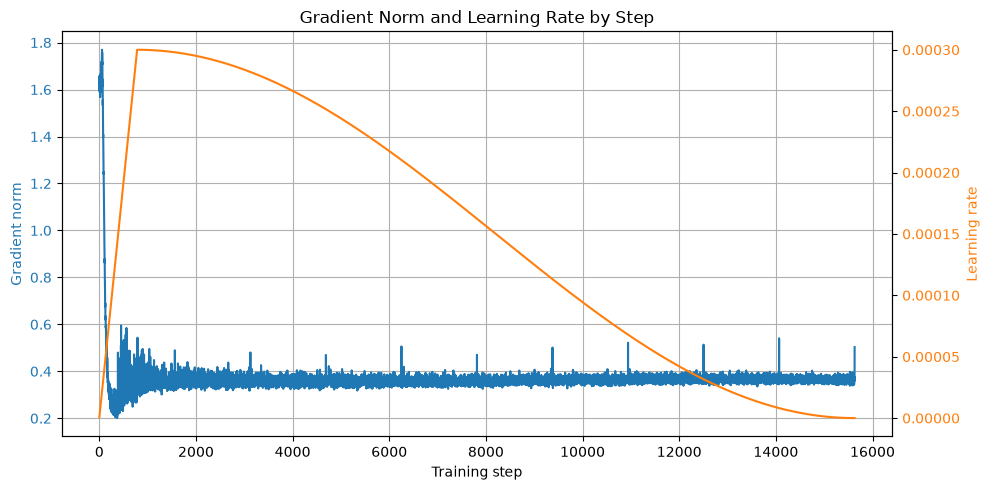

Gradient norm mean: 0.3684396242912351
Gradient norm max: 1.7694355249404907
Gradient norm standard deviation: 0.10082454792095322
Loss spikes: 0
Non-finite values: 0
Gradient plot saved:
outputs/gradient_norm_and_learning_rate.png


In [15]:
# Summarize gradient stability and plot gradient norm/LR

step_metrics_df = pd.DataFrame(step_records)

loss_values = step_metrics_df["loss"].astype(float)
gradient_values = step_metrics_df[
    "gradient_norm"
].astype(float)
learning_rate_values = step_metrics_df[
    "learning_rate"
].astype(float)

rolling_median_loss = loss_values.rolling(
    window=25,
    min_periods=1,
    center=True
).median()

loss_spike_mask = (
    loss_values > 3.0 * rolling_median_loss
)

loss_spike_count = int(loss_spike_mask.sum())

loss_nan_count = int(
    (~np.isfinite(loss_values)).sum()
)

gradient_nan_count = int(
    (~np.isfinite(gradient_values)).sum()
)

learning_rate_nan_count = int(
    (~np.isfinite(learning_rate_values)).sum()
)

stability_summary = {
    "gradient_norm_mean": float(
        gradient_values.mean()
    ),
    "gradient_norm_max": float(
        gradient_values.max()
    ),
    "gradient_norm_std": float(
        gradient_values.std()
    ),
    "loss_spike_count": loss_spike_count,
    "loss_nan_count": loss_nan_count,
    "gradient_nan_count": gradient_nan_count,
    "learning_rate_nan_count": (
        learning_rate_nan_count
    ),
    "total_nonfinite_count": (
        loss_nan_count
        + gradient_nan_count
        + learning_rate_nan_count
    )
}

with (
    OUTPUT_DIR / "gradient_stability_summary.json"
).open("w", encoding="utf-8") as file:
    json.dump(stability_summary, file, indent=2)

# Plot gradient norm and learning rate against training step
fig, gradient_axis = plt.subplots(figsize=(10, 5))

gradient_axis.plot(
    step_metrics_df["step"],
    gradient_values,
    color="tab:blue",
    label="Gradient norm"
)

gradient_axis.set_xlabel("Training step")
gradient_axis.set_ylabel(
    "Gradient norm",
    color="tab:blue"
)
gradient_axis.tick_params(
    axis="y",
    labelcolor="tab:blue"
)
gradient_axis.grid(True)

learning_rate_axis = gradient_axis.twinx()

learning_rate_axis.plot(
    step_metrics_df["step"],
    learning_rate_values,
    color="tab:orange",
    label="Learning rate"
)

learning_rate_axis.set_ylabel(
    "Learning rate",
    color="tab:orange"
)
learning_rate_axis.tick_params(
    axis="y",
    labelcolor="tab:orange"
)

plt.title("Gradient Norm and Learning Rate by Step")
fig.tight_layout()

gradient_plot_path = (
    OUTPUT_DIR / "gradient_norm_and_learning_rate.png"
)

plt.savefig(gradient_plot_path, dpi=150)
plt.show()

print("Gradient norm mean:", stability_summary[
    "gradient_norm_mean"
])
print("Gradient norm max:", stability_summary[
    "gradient_norm_max"
])
print("Gradient norm standard deviation:", stability_summary[
    "gradient_norm_std"
])
print("Loss spikes:", stability_summary[
    "loss_spike_count"
])
print("Non-finite values:", stability_summary[
    "total_nonfinite_count"
])
print("Gradient plot saved:")
print("outputs/gradient_norm_and_learning_rate.png")

In [16]:
# Evaluate train and validation data with dropout disabled

from torch.utils.data import DataLoader, Subset

TRAIN_EVAL_SIZE = 10000

train_eval_dataset = Subset(
    train_dataset,
    range(
        min(
            TRAIN_EVAL_SIZE,
            len(train_dataset)
        )
    )
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=TASK1_CONFIG["batch_size"],
    shuffle=False
)

# Evaluation-mode metrics on 10,000 training sequences
train_eval_metrics = evaluate_model(
    model,
    train_eval_loader
)

# Evaluation-mode validation metrics
validation_metrics = evaluate_model(
    model,
    validation_loader
)

# The running-average training loss was measured with dropout enabled.
dropout_on_training_loss = epoch_records[-1].get(
    "training_loss_dropout_on",
    epoch_records[-1].get("training_loss")
)

dropout_off_training_loss = (
    train_eval_metrics["cross_entropy_loss"]
)

validation_loss = (
    validation_metrics["cross_entropy_loss"]
)

generalization_gap_dropout_off = (
    validation_loss - dropout_off_training_loss
)

generalization_gap_dropout_on = (
    validation_loss - dropout_on_training_loss
)

print("Train metrics with dropout OFF:")
for key, value in train_eval_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nValidation metrics with dropout OFF:")
for key, value in validation_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nTraining loss comparison:")
print(
    "Dropout-ON running-average train loss:",
    f"{dropout_on_training_loss:.4f}"
)
print(
    "Dropout-OFF evaluation train loss:",
    f"{dropout_off_training_loss:.4f}"
)

print("\nGeneralization gaps:")
print(
    "Validation loss - dropout-OFF train loss:",
    f"{generalization_gap_dropout_off:.4f}"
)
print(
    "Validation loss - dropout-ON train loss:",
    f"{generalization_gap_dropout_on:.4f}"
)

evaluation_summary = {
    "train_eval_sequences": len(train_eval_dataset),
    "train_loss_dropout_off": dropout_off_training_loss,
    "train_perplexity_dropout_off": (
        train_eval_metrics["perplexity"]
    ),
    "train_bpc_dropout_off": (
        train_eval_metrics["bits_per_character"]
    ),
    "train_top1_accuracy_dropout_off": (
        train_eval_metrics["top1_accuracy"]
    ),
    "train_loss_dropout_on": dropout_on_training_loss,
    "validation_loss": validation_loss,
    "validation_perplexity": (
        validation_metrics["perplexity"]
    ),
    "validation_bpc": (
        validation_metrics["bits_per_character"]
    ),
    "validation_top1_accuracy": (
        validation_metrics["top1_accuracy"]
    ),
    "generalization_gap_dropout_off": (
        generalization_gap_dropout_off
    ),
    "generalization_gap_dropout_on": (
        generalization_gap_dropout_on
    )
}

with (
    OUTPUT_DIR / "evaluation_summary.json"
).open("w", encoding="utf-8") as file:
    json.dump(evaluation_summary, file, indent=2)

print("\nEvaluation summary saved:")
print("outputs/evaluation_summary.json")

Train metrics with dropout OFF:
cross_entropy_loss: 0.8433
perplexity: 2.3241
bits_per_character: 1.2167
top1_accuracy: 0.7321

Validation metrics with dropout OFF:
cross_entropy_loss: 0.8728
perplexity: 2.3935
bits_per_character: 1.2591
top1_accuracy: 0.7253

Training loss comparison:
Dropout-ON running-average train loss: 0.9062
Dropout-OFF evaluation train loss: 0.8433

Generalization gaps:
Validation loss - dropout-OFF train loss: 0.0294
Validation loss - dropout-ON train loss: -0.0334

Evaluation summary saved:
outputs/evaluation_summary.json


In [17]:
# Save the final model checkpoint with evaluation results

final_checkpoint_path = CHECKPOINT_DIR / "final_model.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "char_to_idx": char_to_idx,
    "idx_to_char": idx_to_char,
    "vocab_size": vocab_size,
    "config": TASK1_CONFIG,
    "evaluation_summary": evaluation_summary,
    "resource_metadata": resource_metadata,
    "parameter_count": parameter_count,
}, final_checkpoint_path)

print("Final checkpoint saved:")
print("checkpoints/final_model.pt")

Final checkpoint saved:
checkpoints/final_model.pt


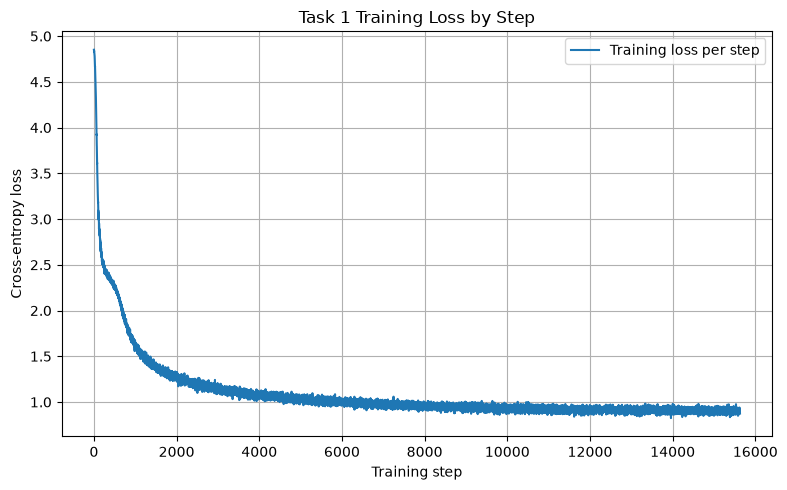

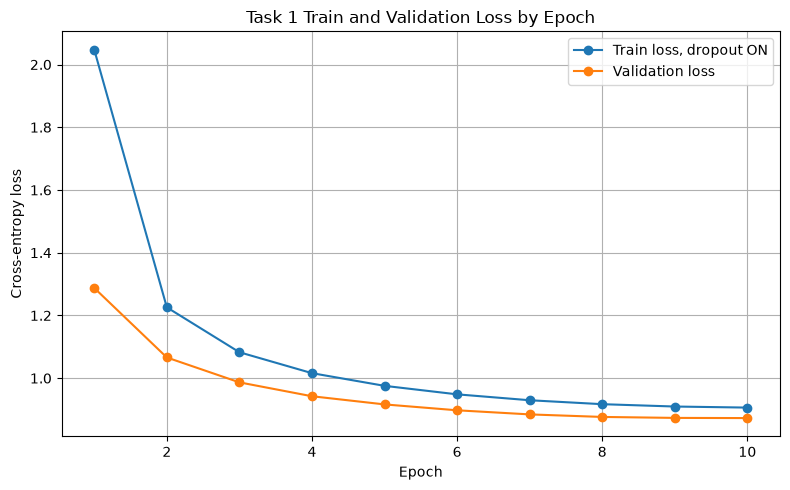

Per-step loss plot saved:
outputs/final_training_loss.png
Per-epoch loss curves saved:
outputs/loss_curves.png


In [18]:
# Save the per-step loss plot and the required per-epoch loss curves

# Existing per-step training loss plot
step_losses = [
    record["loss"]
    for record in step_records
]

step_loss_path = OUTPUT_DIR / "final_training_loss.png"

plt.figure(figsize=(8, 5))
plt.plot(step_losses, label="Training loss per step")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Task 1 Training Loss by Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(step_loss_path, dpi=150)
plt.show()

# Required single figure: per-epoch train loss vs validation loss
epoch_numbers = [
    record["epoch"]
    for record in epoch_records
]

epoch_train_losses = [
    record["training_loss_dropout_on"]
    for record in epoch_records
]

epoch_validation_losses = [
    record["validation_loss"]
    for record in epoch_records
]

epoch_loss_curve_path = OUTPUT_DIR / "loss_curves.png"

plt.figure(figsize=(8, 5))
plt.plot(
    epoch_numbers,
    epoch_train_losses,
    marker="o",
    label="Train loss, dropout ON"
)
plt.plot(
    epoch_numbers,
    epoch_validation_losses,
    marker="o",
    label="Validation loss"
)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Task 1 Train and Validation Loss by Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(epoch_loss_curve_path, dpi=150)
plt.show()

print("Per-step loss plot saved:")
print("outputs/final_training_loss.png")

print("Per-epoch loss curves saved:")
print("outputs/loss_curves.png")

## Final GPU Text Generation

This section evaluates the trained character-level GPT model by generating new text one character at a time.

The model receives a starting prompt, predicts the next character, appends it to the sequence, and repeats this process. The causal attention mask ensures that each prediction uses only the current and previous characters.

These samples were generated after training on 100,000 training sequences for 10 epochs using the NVIDIA GeForce RTX 4090 GPU.

In [20]:
# Final generation experiment:
# 100 samples x 200 new characters for four temperatures

import json
import re
import time
from collections import Counter

import yaml


# Load the root-level configuration
CONFIG_PATH = PROJECT_ROOT / "task1_llm" / "config.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    CONFIG = yaml.safe_load(file) or {}

# Repair the configuration if generation settings are missing
if "generation" not in CONFIG:
    CONFIG["generation"] = {
        "samples_per_setting": 100,
        "new_characters": 200,
        "timing_characters": 500,
        "temperatures": [
            0.0,
            0.5,
            0.8,
            1.0
        ]
    }

    with CONFIG_PATH.open("w", encoding="utf-8") as file:
        yaml.safe_dump(
            CONFIG,
            file,
            sort_keys=False
        )

print("Loaded configuration:")
print("task1_llm/config.yaml")
print("Config sections:", list(CONFIG.keys()))

GENERATION_CONFIG = CONFIG["generation"]

SAMPLES_PER_SETTING = int(
    GENERATION_CONFIG["samples_per_setting"]
)

NEW_CHARACTERS = int(
    GENERATION_CONFIG["new_characters"]
)

TIMING_CHARACTERS = int(
    GENERATION_CONFIG["timing_characters"]
)

TEMPERATURES = [
    float(value)
    for value in GENERATION_CONFIG["temperatures"]
]

GENERATION_PROMPTS = [
    "Once upon a time",
    "One day, a little girl",
    "The boy went to the",
    "Lily found a small",
    "Tom wanted to help",
    "The dog ran across",
    "A family visited the",
    "The children decided to",
    "Mia opened the door",
    "Ben saw something strange",
    "The cat was sitting",
    "Everyone was happy when",
    "The teacher asked the",
    "A little bird flew",
    "The friends played in",
    "The girl looked at",
    "After breakfast, the boy",
    "The parents told their",
    "A bear walked into",
    "The new toy was"
]


def synchronize_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


@torch.no_grad()
def generate_text_with_continuation(
    model,
    prompt,
    max_new_characters=200,
    temperature=0.8
):
    model.eval()

    prompt = "".join(
        character
        for character in prompt
        if character in char_to_idx
    )

    if not prompt:
        prompt = " "

    prompt_ids, _ = encode(prompt)

    generated_ids = torch.tensor(
        [prompt_ids],
        dtype=torch.long,
        device=DEVICE
    )

    for _ in range(max_new_characters):
        input_ids = generated_ids[
            :, -TASK1_CONFIG["context_length"] :
        ]

        logits, _ = model(input_ids)
        next_token_logits = logits[:, -1, :]

        if temperature == 0.0:
            next_token = torch.argmax(
                next_token_logits,
                dim=-1,
                keepdim=True
            )
        else:
            probabilities = F.softmax(
                next_token_logits / temperature,
                dim=-1
            )

            next_token = torch.multinomial(
                probabilities,
                num_samples=1
            )

        generated_ids = torch.cat(
            [generated_ids, next_token],
            dim=1
        )

    full_text = decode(
        generated_ids[0].tolist()
    )

    continuation = full_text[len(prompt):]

    model.train()

    return {
        "prompt": prompt,
        "continuation": continuation,
        "full_text": full_text
    }


def get_character_ngrams(text, n):
    return [
        text[index:index + n]
        for index in range(len(text) - n + 1)
    ]


def get_word_tokens(text):
    return re.findall(
        r"\b[a-zA-Z0-9']+\b",
        text.lower()
    )


def get_word_ngrams(text, n):
    words = get_word_tokens(text)

    return [
        tuple(words[index:index + n])
        for index in range(len(words) - n + 1)
    ]


def distinct_score(values):
    if not values:
        return 0.0

    return len(set(values)) / len(values)


def repeated_rate(values):
    if not values:
        return 0.0

    counts = Counter(values)

    repeated_count = sum(
        count - 1
        for count in counts.values()
        if count > 1
    )

    return repeated_count / len(values)


def calculate_sample_metrics(text):
    return {
        "distinct_1_char": distinct_score(
            get_character_ngrams(text, 1)
        ),
        "distinct_2_char": distinct_score(
            get_character_ngrams(text, 2)
        ),
        "distinct_3_char": distinct_score(
            get_character_ngrams(text, 3)
        ),
        "repeated_4gram_rate_char": repeated_rate(
            get_character_ngrams(text, 4)
        ),
        "distinct_1_word": distinct_score(
            get_word_ngrams(text, 1)
        ),
        "distinct_2_word": distinct_score(
            get_word_ngrams(text, 2)
        ),
        "distinct_3_word": distinct_score(
            get_word_ngrams(text, 3)
        ),
        "repeated_4gram_rate_word": repeated_rate(
            get_word_ngrams(text, 4)
        )
    }


all_generation_records = []
generation_summary = {}

for temperature in TEMPERATURES:
    setting_records = []

    for sample_index in range(
        SAMPLES_PER_SETTING
    ):
        prompt = GENERATION_PROMPTS[
            sample_index % len(GENERATION_PROMPTS)
        ]

        result = generate_text_with_continuation(
            model=model,
            prompt=prompt,
            max_new_characters=NEW_CHARACTERS,
            temperature=temperature
        )

        record = {
            "temperature": temperature,
            "sample_index": sample_index + 1,
            "prompt": result["prompt"],
            "continuation": result["continuation"],
            "full_text": result["full_text"],
            "metrics": calculate_sample_metrics(
                result["continuation"]
            )
        }

        setting_records.append(record)
        all_generation_records.append(record)

    metric_names = list(
        setting_records[0]["metrics"].keys()
    )

    generation_summary[str(temperature)] = {
        metric_name: float(
            np.mean([
                record["metrics"][metric_name]
                for record in setting_records
            ])
        )
        for metric_name in metric_names
    }


# Measure generation speed using 500 generated characters
synchronize_cuda()
generation_start_time = time.perf_counter()

_ = generate_text_with_continuation(
    model=model,
    prompt="Once upon a time",
    max_new_characters=TIMING_CHARACTERS,
    temperature=0.8
)

synchronize_cuda()

generation_elapsed_seconds = (
    time.perf_counter() - generation_start_time
)

generation_tokens_per_second = (
    TIMING_CHARACTERS
    / max(generation_elapsed_seconds, 1e-9)
)

generation_resource_metadata = {
    "timed_generated_characters": TIMING_CHARACTERS,
    "generation_elapsed_seconds": (
        generation_elapsed_seconds
    ),
    "generation_tokens_per_second": (
        generation_tokens_per_second
    )
}


# Save all samples and metrics
with (
    OUTPUT_DIR / "final_generation_samples.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        all_generation_records,
        file,
        indent=2,
        ensure_ascii=False
    )

with (
    OUTPUT_DIR / "final_generation_metrics.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        generation_summary,
        file,
        indent=2
    )

with (
    OUTPUT_DIR / "generation_resource_metadata.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        generation_resource_metadata,
        file,
        indent=2
    )


# Print five samples for manual failure review
print("Five readable samples for manual review:")

review_records = [
    record
    for record in all_generation_records
    if record["temperature"] == 0.8
][:5]

for record in review_records:
    print("\n" + "=" * 80)
    print("Temperature:", record["temperature"])
    print("Prompt:", record["prompt"])
    print(record["continuation"])

print("\nGeneration summary:")

for temperature, metrics in generation_summary.items():
    print(f"\nTemperature {temperature}:")

    for metric_name, metric_value in metrics.items():
        print(
            f"{metric_name}: {metric_value:.4f}"
        )

print(
    "\nGeneration speed:",
    f"{generation_tokens_per_second:.2f}",
    "characters per second"
)

print("Generated samples saved:")
print("outputs/final_generation_samples.json")
print("outputs/final_generation_metrics.json")

Loaded configuration:
task1_llm/config.yaml
Config sections: ['seed', 'member_id', 'paths', 'dataset', 'model', 'training', 'generation']
Five readable samples for manual review:

Temperature: 0.8
Prompt: Once upon a time
, there was a little girl named Lily. She had a toy to play with her new colors and make the fields. One day, Lily went to the park with her mom and dad. They were cool as the best friends.
Max and Da

Temperature: 0.8
Prompt: One day, a little girl
 named Lily. She loved to play with her mommy and daddy. One day, her mom was very sad. She was brave and the incredible the big oak and saw what was. It was so window. It was the captain! She took th

Temperature: 0.8
Prompt: The boy went to the
 fire and climbed up the ground. The end.
Once upon a time, there was a little girl named Lily. She loved to play with her toys and hurt herself on the sky. One day, a shiny pant made sure to find the

Temperature: 0.8
Prompt: Lily found a small
 little boy came in. They were happ

## Final Generation Metrics

This section measures the diversity of the final generated samples.

Distinct-1, Distinct-2, and Distinct-3 measure the proportion of unique 1-, 2-, and 3-character sequences. The repeated 4-gram rate measures how often four-character sequences are repeated.

These metrics were calculated from samples generated by the final GPU-trained model.

## Final Task 1 Failure Analysis

This section analyzes failure modes observed in the final generated samples.

The model was trained for 10 epochs on 100,000 TinyStories training sequences using the NVIDIA GeForce RTX 4090 GPU. The analysis considers grammar, coherence, repetition, spelling, and story continuation quality.

In [21]:
# Create empty templates for manual writing.
# No automatically generated analysis is added.

results_template = """# Task 1 Results

## Configuration

## Dataset

## Training Results

## Validation Results

## Generation Results

## Resource Usage

## Checkpoint Mapping
"""

failure_analysis_template = """# Task 1 Failure Analysis

## Failure Case 1

## Failure Case 2

## Failure Case 3

## Additional Observations
"""

(TASK_ROOT / "results.md").write_text(
    results_template,
    encoding="utf-8"
)

(TASK_ROOT / "failure_analysis.md").write_text(
    failure_analysis_template,
    encoding="utf-8"
)

print("Created empty results template:")
print("task1_llm/Vrishin/results.md")

print("Created empty failure-analysis template:")
print("task1_llm/Vrishin/failure_analysis.md")

Created empty results template:
task1_llm/Vrishin/results.md
Created empty failure-analysis template:
task1_llm/Vrishin/failure_analysis.md


In [ ]:
# Create the final metrics report, manifest, environment file,
# README reproduction commands, and repository ignore rules.

import tempfile
import shutil
import subprocess
import json
import sys
import pandas as pd

report_rows = []


def add_report_metric(metric, value, source):
    report_rows.append({
        "metric": metric,
        "value": value,
        "source": source
    })


# Train and validation metrics
add_report_metric(
    "train_cross_entropy_dropout_off",
    evaluation_summary["train_loss_dropout_off"],
    "train_evaluation"
)

add_report_metric(
    "train_perplexity_dropout_off",
    evaluation_summary["train_perplexity_dropout_off"],
    "train_evaluation"
)

add_report_metric(
    "train_bpc_dropout_off",
    evaluation_summary["train_bpc_dropout_off"],
    "train_evaluation"
)

add_report_metric(
    "train_top1_accuracy_dropout_off",
    evaluation_summary["train_top1_accuracy_dropout_off"],
    "train_evaluation"
)

add_report_metric(
    "train_cross_entropy_dropout_on",
    evaluation_summary["train_loss_dropout_on"],
    "training_log"
)

add_report_metric(
    "validation_cross_entropy",
    evaluation_summary["validation_loss"],
    "validation_evaluation"
)

add_report_metric(
    "validation_perplexity",
    evaluation_summary["validation_perplexity"],
    "validation_evaluation"
)

add_report_metric(
    "validation_bpc",
    evaluation_summary["validation_bpc"],
    "validation_evaluation"
)

add_report_metric(
    "validation_top1_accuracy",
    evaluation_summary["validation_top1_accuracy"],
    "validation_evaluation"
)

add_report_metric(
    "generalization_gap_dropout_off",
    evaluation_summary["generalization_gap_dropout_off"],
    "evaluation"
)

add_report_metric(
    "generalization_gap_dropout_on",
    evaluation_summary["generalization_gap_dropout_on"],
    "evaluation"
)


# Generation metrics for every temperature
for temperature, metrics in generation_summary.items():
    for metric_name, metric_value in metrics.items():
        add_report_metric(
            f"{metric_name}_temperature_{temperature}",
            metric_value,
            "generation"
        )


# Training stability metrics
for metric_name, metric_value in stability_summary.items():
    add_report_metric(
        metric_name,
        metric_value,
        "training_stability"
    )


# Resource metrics
resource_metric_names = [
    "parameter_count",
    "total_training_time_seconds",
    "training_tokens_per_second",
    "peak_memory_allocated_gb",
    "peak_memory_reserved_gb"
]

for metric_name in resource_metric_names:
    add_report_metric(
        metric_name,
        resource_metadata[metric_name],
        "training_resources"
    )

add_report_metric(
    "generation_tokens_per_second",
    generation_resource_metadata[
        "generation_tokens_per_second"
    ],
    "generation_resources"
)

add_report_metric(
    "generation_elapsed_seconds",
    generation_resource_metadata[
        "generation_elapsed_seconds"
    ],
    "generation_resources"
)


# Save the required metrics report
metrics_report_df = pd.DataFrame(report_rows)

metrics_report_df.to_csv(
    OUTPUT_DIR / "metrics_report.csv",
    index=False
)


# Checkpoint mapping
checkpoint_mapping = {
    "report_uses": "final_model.pt",
    "best_model.pt": {
        "selection_rule": "lowest validation loss",
        "validation_loss": float(best_validation_loss)
    },
    "final_model.pt": {
        "selection_rule": "model after final training epoch",
        "validation_loss": float(
            evaluation_summary["validation_loss"]
        ),
        "validation_top1_accuracy": float(
            evaluation_summary[
                "validation_top1_accuracy"
            ]
        )
    }
}


# Save manifest
manifest = {
    "seed": int(SEED),
    "dataset": CONFIG["dataset"]["name"],
    "train_sequences": int(
        TASK1_CONFIG["train_sequences"]
    ),
    "validation_sequences": int(
        TASK1_CONFIG["validation_sequences"]
    ),
    "context_length": int(
        TASK1_CONFIG["context_length"]
    ),
    "configuration": TASK1_CONFIG,
    "hardware": resource_metadata,
    "generation_resources": generation_resource_metadata,
    "checkpoint_mapping": checkpoint_mapping,
    "report_file": "outputs/metrics_report.csv"
}

with (
    TASK_ROOT / "manifest.json"
).open("w", encoding="utf-8") as file:
    json.dump(manifest, file, indent=2)


# Save pip freeze and environment information
pip_freeze_result = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True,
    check=False
)

environment_text = (
    "# Python environment\n\n"
    f"Python executable: {sys.executable}\n"
    f"Python version: {sys.version}\n"
    f"PyTorch version: {torch.__version__}\n"
    f"CUDA version: {torch.version.cuda}\n"
    f"Device: {DEVICE}\n\n"
    "# pip freeze\n\n"
    f"{pip_freeze_result.stdout}"
)

(
    TASK_ROOT / "environment_manifest.txt"
).write_text(
    environment_text,
    encoding="utf-8"
)


# Add repository ignore rules without deleting existing content
gitignore_path = PROJECT_ROOT / ".gitignore"

ignore_rules = [
    ".venv/",
    "hf_cache/",
    "DATA266_GPU_RTX4090_final.ipynb",
    "DATA266_Lab1_hf_cache/",
    "**/__pycache__/",
    "**/.ipynb_checkpoints/",
    "task1_llm/data/"
]

existing_gitignore = ""

if gitignore_path.exists():
    existing_gitignore = gitignore_path.read_text(
        encoding="utf-8"
    )

missing_rules = [
    rule
    for rule in ignore_rules
    if rule not in existing_gitignore
]

if missing_rules:
    updated_gitignore = (
        existing_gitignore.rstrip()
        + "\n\n# DATA266 generated/cache files\n"
        + "\n".join(missing_rules)
        + "\n"
    )

    gitignore_path.write_text(
        updated_gitignore,
        encoding="utf-8"
    )


# Add README reproduction commands
# Add README reproduction commands
readme_path = TASK_ROOT / "README.md"

readme_snippet = "\n".join([
    "## Reproduction commands",
    "",
    "From the DATA266_Lab1 project root, select the DATA266 GPU Lab",
    "Jupyter kernel.",
    "",
    "Short smoke test:",
    "",
    "Use a small dataset subset and one epoch in config.yaml,",
    "then run the notebook from beginning to end.",
    "",
    "Full run:",
    "",
    "Restore the full configuration in config.yaml,",
    "then run all notebook cells from beginning to end.",
    "",
    "Dataset reference:",
    "",
    "Add the read-only Google Drive link to the shared dataset ZIP here.",
    ""
])

if readme_path.exists():
    current_readme = readme_path.read_text(
        encoding="utf-8"
    )
else:
    current_readme = ""

if "## Reproduction commands" not in current_readme:
    readme_path.write_text(
        current_readme.rstrip()
        + "\n\n"
        + readme_snippet,
        encoding="utf-8"
    )

print("Metrics report saved:")
print("outputs/metrics_report.csv")

print("Manifest saved:")
print("Vrishin/manifest.json")

print("Environment manifest saved:")
print("Vrishin/environment_manifest.txt")

print("README and .gitignore updated.")

Metrics report saved:
outputs/metrics_report.csv
Manifest saved:
Vrishin/manifest.json
Environment manifest saved:
Vrishin/environment_manifest.txt
README and .gitignore updated.


In [1]:
from pathlib import Path
import json
import csv
import yaml


# Locate the DATA266_Lab1 project root
current_path = Path.cwd().resolve()

possible_roots = [
    path
    for path in [current_path, *current_path.parents]
    if path.name == "DATA266_Lab1" and path.is_dir()
]

if possible_roots:
    project_root = possible_roots[0]
elif (current_path / "DATA266_Lab1").is_dir():
    project_root = current_path / "DATA266_Lab1"
else:
    raise FileNotFoundError(
        "Could not locate the DATA266_Lab1 project folder."
    )


# Load config.yaml
config_path = project_root / "task1_llm" / "config.yaml"

with config_path.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)


member_dir = config.get("paths", {}).get(
    "member_dir",
    "task1_llm/Vrishin"
)

task_root = project_root / member_dir
outputs_dir = task_root / "outputs"

manifest_path = task_root / "manifest.json"
metrics_path = outputs_dir / "metrics_report.csv"
epoch_metrics_path = outputs_dir / "final_epoch_metrics.csv"
generation_metrics_path = (
    outputs_dir / "final_generation_metrics.json"
)


def load_json(path, default=None):
    if not path.exists():
        return default if default is not None else {}

    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_metrics_csv(path):
    metrics = {}

    if not path.exists():
        return metrics

    with path.open(
        "r",
        encoding="utf-8",
        newline=""
    ) as file:
        reader = csv.DictReader(file)

        for row in reader:
            metric_name = row.get("metric", "")
            metric_value = row.get("value", "")

            if metric_name:
                metrics[metric_name] = metric_value

    return metrics


manifest = load_json(manifest_path)
metrics = load_metrics_csv(metrics_path)
generation_metrics = load_json(generation_metrics_path)

configuration = manifest.get("configuration", {})
hardware = manifest.get("hardware", {})
generation_resources = manifest.get(
    "generation_resources",
    {}
)

checkpoint_mapping = manifest.get(
    "checkpoint_mapping",
    {}
)


def metric(name, fallback="Not available"):
    return metrics.get(name, fallback)


def generation_value(temperature, name):
    temperature_metrics = generation_metrics.get(
        str(temperature),
        {}
    )

    return temperature_metrics.get(
        name,
        "Not available"
    )


results_text = f"""# Task 1 Results

## Configuration

- Dataset: {manifest.get("dataset", "TinyStories")}
- Seed: {manifest.get("seed", "Not available")}
- Context length: {manifest.get("context_length", "Not available")}
- Training sequences: {manifest.get("train_sequences", "Not available")}
- Validation sequences: {manifest.get("validation_sequences", "Not available")}
- Epochs: {configuration.get("epochs", "Not available")}
- Batch size: {configuration.get("batch_size", "Not available")}
- Embedding dimension: {configuration.get("embedding_dim", "Not available")}
- Transformer layers: {configuration.get("num_layers", "Not available")}
- Attention heads: {configuration.get("num_heads", "Not available")}
- Dropout: {configuration.get("dropout", "Not available")}
- Learning rate: {configuration.get("learning_rate", "Not available")}
- Gradient clipping norm: {configuration.get("gradient_clip_norm", "Not available")}
- Parameters: {hardware.get("parameter_count", "Not available")}

## Dataset

The model uses a character-level TinyStories dataset.

The vocabulary was built from the training split only. Validation characters not found in the training vocabulary were mapped to the explicit `<UNK>` token.

The required 100K/10K interpretation is:

- 100,000 training sequences
- 10,000 validation sequences
- 128 input characters per sequence
- 129 characters total per example including the shifted target

## Training Results

| Metric | Value |
|---|---:|
| Training CE, dropout ON | {metric("train_cross_entropy_dropout_on")} |
| Training CE, dropout OFF | {metric("train_cross_entropy_dropout_off")} |
| Training perplexity, dropout OFF | {metric("train_perplexity_dropout_off")} |
| Training BPC, dropout OFF | {metric("train_bpc_dropout_off")} |
| Training top-1 accuracy, dropout OFF | {metric("train_top1_accuracy_dropout_off")} |
| Validation CE | {metric("validation_cross_entropy")} |
| Validation perplexity | {metric("validation_perplexity")} |
| Validation BPC | {metric("validation_bpc")} |
| Validation top-1 accuracy | {metric("validation_top1_accuracy")} |
| Generalization gap, dropout OFF | {metric("generalization_gap_dropout_off")} |
| Generalization gap, dropout ON | {metric("generalization_gap_dropout_on")} |

The dropout-off generalization gap is the preferred comparison because both training and validation metrics are evaluated with dropout disabled.

## Generation Results

Generation metrics were computed on the continuation only, excluding the prompt.

| Temperature | Distinct-1 Char | Distinct-2 Char | Distinct-3 Char | Repeated 4-gram Char |
|---:|---:|---:|---:|---:|
| 0.0 | {generation_value(0.0, "distinct_1_char")} | {generation_value(0.0, "distinct_2_char")} | {generation_value(0.0, "distinct_3_char")} | {generation_value(0.0, "repeated_4gram_rate_char")} |
| 0.5 | {generation_value(0.5, "distinct_1_char")} | {generation_value(0.5, "distinct_2_char")} | {generation_value(0.5, "distinct_3_char")} | {generation_value(0.5, "repeated_4gram_rate_char")} |
| 0.8 | {generation_value(0.8, "distinct_1_char")} | {generation_value(0.8, "distinct_2_char")} | {generation_value(0.8, "distinct_3_char")} | {generation_value(0.8, "repeated_4gram_rate_char")} |
| 1.0 | {generation_value(1.0, "distinct_1_char")} | {generation_value(1.0, "distinct_2_char")} | {generation_value(1.0, "distinct_3_char")} | {generation_value(1.0, "repeated_4gram_rate_char")} |

## Resource Usage

- GPU: {hardware.get("gpu_name", "Not available")}
- Device: {hardware.get("device", "Not available")}
- PyTorch: {hardware.get("pytorch", "Not available")}
- CUDA: {hardware.get("cuda_version", "Not available")}
- Training time: {hardware.get("total_training_time_seconds", "Not available")} seconds
- Training tokens per second: {hardware.get("training_tokens_per_second", "Not available")}
- Peak allocated memory: {hardware.get("peak_memory_allocated_gb", "Not available")} GB
- Peak reserved memory: {hardware.get("peak_memory_reserved_gb", "Not available")} GB
- Generation speed: {generation_resources.get("generation_tokens_per_second", "Not available")} characters per second

## Training Stability

- Mean gradient norm: {metric("gradient_norm_mean")}
- Maximum gradient norm: {metric("gradient_norm_max")}
- Gradient norm standard deviation: {metric("gradient_norm_std")}
- Loss spikes: {metric("loss_spike_count")}
- Non-finite values: {metric("total_nonfinite_count")}

## Checkpoint Mapping

- Reported checkpoint: `{checkpoint_mapping.get("report_uses", "final_model.pt")}`
- Best checkpoint: `best_model.pt`
- Final checkpoint: `final_model.pt`
- Best-checkpoint selection rule: lowest validation loss

## Saved Artifacts

- `checkpoints/best_model.pt`
- `checkpoints/final_model.pt`
- `outputs/metrics_report.csv`
- `outputs/final_epoch_metrics.csv`
- `outputs/final_training_loss.png`
- `outputs/loss_curves.png`
- `outputs/gradient_norm_and_learning_rate.png`
- `outputs/final_generation_samples.json`
- `outputs/final_generation_metrics.json`
- `logs/train_raw.log`
"""


results_path = task_root / "results.md"
results_path.write_text(
    results_text,
    encoding="utf-8"
)

print("Report created successfully:")
print(results_path)

Report created successfully:
C:\Users\Vrishin Dharmesh KP\OneDrive\Documents\Data 266 GenAI and LLM\lab1\DATA266_Lab1\task1_llm\Vrishin\results.md


In [5]:
# Create an aesthetic, fixed-size Task 1 PDF report
# This cell only reads existing files. It does not train or evaluate the model.

from pathlib import Path
import csv
import json
import textwrap

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle


# ------------------------------------------------------------
# Locate project folders
# ------------------------------------------------------------

current_path = Path.cwd().resolve()

project_root = None

for path in [current_path, *current_path.parents]:
    if path.name == "DATA266_Lab1":
        project_root = path
        break

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the DATA266_Lab1 project folder."
    )


candidate_task_roots = [
    project_root / "task1_llm" / "Vrishin",
    project_root / "task1_llm" / "member_Vrishin",
]

task_root = next(
    (
        path for path in candidate_task_roots
        if path.exists()
    ),
    None
)

if task_root is None:
    raise FileNotFoundError(
        "Could not locate the Task 1 member folder."
    )


outputs_dir = task_root / "outputs"
report_path = task_root / "report.pdf"


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def load_json(path):
    if not path.exists():
        return {}

    try:
        with path.open("r", encoding="utf-8") as file:
            return json.load(file)
    except Exception:
        return {}


def load_csv(path):
    if not path.exists():
        return []

    with path.open(
        "r",
        encoding="utf-8",
        newline=""
    ) as file:
        return list(csv.DictReader(file))


def find_metric(metric_rows, possible_names):
    for row in metric_rows:
        metric_name = row.get("metric", "").lower()

        for possible_name in possible_names:
            if possible_name.lower() in metric_name:
                return row.get("value", "NOT_AVAILABLE")

    return "NOT_AVAILABLE"


def wrap_lines(text, width=96):
    wrapped = []

    for line in str(text).split("\n"):
        if line.strip():
            wrapped.extend(
                textwrap.wrap(
                    line,
                    width=width,
                    break_long_words=False,
                    break_on_hyphens=False
                )
            )
        else:
            wrapped.append("")

    return wrapped


# ------------------------------------------------------------
# Load existing results
# ------------------------------------------------------------

manifest = load_json(
    task_root / "manifest.json"
)

metric_rows = load_csv(
    outputs_dir / "metrics_report.csv"
)

epoch_rows = load_csv(
    outputs_dir / "final_epoch_metrics.csv"
)

generation_metrics = load_json(
    outputs_dir / "final_generation_metrics.json"
)

evaluation_summary = load_json(
    outputs_dir / "evaluation_summary.json"
)

configuration = manifest.get(
    "configuration",
    {}
)

hardware = manifest.get(
    "hardware",
    {}
)

generation_resources = manifest.get(
    "generation_resources",
    {}
)

checkpoint_mapping = manifest.get(
    "checkpoint_mapping",
    {}
)


# ------------------------------------------------------------
# Fixed-size aesthetic PDF page creator
# ------------------------------------------------------------

PAGE_WIDTH = 8.5
PAGE_HEIGHT = 11
page_number = 0


def add_page(pdf, title, content):
    global page_number

    lines = wrap_lines(content)
    lines_per_page = 45

    chunks = [
        lines[index:index + lines_per_page]
        for index in range(
            0,
            len(lines),
            lines_per_page
        )
    ]

    if not chunks:
        chunks = [[""]]

    for chunk_index, chunk in enumerate(chunks):
        page_number += 1

        page_title = title

        if len(chunks) > 1:
            page_title = (
                f"{title} "
                f"(Page {chunk_index + 1}/{len(chunks)})"
            )

        figure = plt.figure(
            figsize=(PAGE_WIDTH, PAGE_HEIGHT),
            dpi=150
        )

        figure.patch.set_facecolor("#F5F7FB")

        # Dark blue header
        figure.patches.append(
            Rectangle(
                (0, 0.91),
                1,
                0.09,
                transform=figure.transFigure,
                facecolor="#17365D",
                edgecolor="none"
            )
        )

        # Blue accent line
        figure.patches.append(
            Rectangle(
                (0, 0.905),
                1,
                0.005,
                transform=figure.transFigure,
                facecolor="#4F81BD",
                edgecolor="none"
            )
        )

        # White content panel
        figure.patches.append(
            Rectangle(
                (0.055, 0.105),
                0.89,
                0.765,
                transform=figure.transFigure,
                facecolor="white",
                edgecolor="#D6DEE8",
                linewidth=1.0
            )
        )

        # Header label
        figure.text(
            0.07,
            0.958,
            "DATA 266 | LAB 1 | TASK 1",
            fontsize=9,
            color="#D9EAF7",
            fontweight="bold",
            va="center"
        )

        # Header title
        figure.text(
            0.07,
            0.927,
            page_title,
            fontsize=16,
            color="white",
            fontweight="bold",
            va="center"
        )

        # Main content
        figure.text(
            0.08,
            0.845,
            "\n".join(chunk),
            fontsize=9.4,
            color="#1F2937",
            va="top",
            linespacing=1.35
        )

        # Footer separator
        figure.patches.append(
            Rectangle(
                (0.07, 0.075),
                0.86,
                0.0015,
                transform=figure.transFigure,
                facecolor="#B4C7E7",
                edgecolor="none"
            )
        )

        # Footer text
        figure.text(
            0.07,
            0.045,
            "Character-level GPT trained on TinyStories",
            fontsize=8,
            color="#5B6573",
            va="center"
        )

        figure.text(
            0.93,
            0.045,
            f"Page {page_number}",
            fontsize=8,
            color="#5B6573",
            ha="right",
            va="center"
        )

        # Important: no bbox_inches='tight'
        # This keeps every page exactly the same size.
        pdf.savefig(figure)
        plt.close(figure)


# ------------------------------------------------------------
# Page 1: Overview
# ------------------------------------------------------------

add_page(
    pdf,
    "Task 1 Overview",
    f"""Student: Vrishin
Dataset: {manifest.get("dataset", "TinyStories")}
Seed: {manifest.get("seed", "8844")}

This report summarizes the completed character-level GPT language-model
experiment. The report was generated from the existing metrics, checkpoint,
manifest, and generation files. No training or evaluation was performed
while creating this PDF.

The model was implemented from scratch using PyTorch and trained on
TinyStories using character-level next-token prediction."""
)


# ------------------------------------------------------------
# Page 2: Architecture
# ------------------------------------------------------------

add_page(
    pdf,
    "Model Architecture",
    f"""The model is a decoder-only character-level GPT.

Architecture configuration:

- Character vocabulary size: {manifest.get("vocab_size", "See notebook output")}
- Embedding dimension: {configuration.get("embedding_dim", "NOT_AVAILABLE")}
- Transformer layers: {configuration.get("num_layers", "NOT_AVAILABLE")}
- Attention heads: {configuration.get("num_heads", "NOT_AVAILABLE")}
- Context length: {configuration.get("context_length", "NOT_AVAILABLE")}
- Dropout: {configuration.get("dropout", "NOT_AVAILABLE")}
- Parameter count: {hardware.get("parameter_count", "NOT_AVAILABLE")}

The input is a sequence of characters. The embedding layer converts each
character into a vector representation. Causal multi-head self-attention
allows each position to use only the current and previous characters.
The final linear layer produces logits for the next-character prediction.

The target sequence is shifted by one character relative to the input.
Therefore, the model learns autoregressive next-character prediction."""
)


# ------------------------------------------------------------
# Page 3: Dataset and training configuration
# ------------------------------------------------------------

add_page(
    pdf,
    "Dataset and Training Configuration",
    f"""Dataset: {manifest.get("dataset", "TinyStories")}
Training sequences: {manifest.get("train_sequences", "NOT_AVAILABLE")}
Validation sequences: {manifest.get("validation_sequences", "NOT_AVAILABLE")}
Context length: {manifest.get("context_length", "NOT_AVAILABLE")}
Epochs: {configuration.get("epochs", "NOT_AVAILABLE")}
Batch size: {configuration.get("batch_size", "NOT_AVAILABLE")}
Learning rate: {configuration.get("learning_rate", "NOT_AVAILABLE")}
Weight decay: {configuration.get("weight_decay", "NOT_AVAILABLE")}
Warmup fraction: {configuration.get("warmup_fraction", "NOT_AVAILABLE")}
Gradient clipping norm: {configuration.get("gradient_clip_norm", "NOT_AVAILABLE")}

The 100K/10K dataset interpretation is:

- 100,000 training sequences
- 10,000 validation sequences
- 128 input characters per sequence
- 129 characters including the shifted target

The vocabulary was built from the training split only. Validation characters
not found in the training vocabulary were mapped explicitly to <UNK>."""
)


# ------------------------------------------------------------
# Page 4: Main metrics
# ------------------------------------------------------------

add_page(
    pdf,
    "Training and Validation Metrics",
    f"""Training CE, dropout ON:
{find_metric(metric_rows, ["train_cross_entropy_dropout_on"])}

Training CE, dropout OFF:
{find_metric(metric_rows, ["train_cross_entropy_dropout_off"])}

Training perplexity:
{find_metric(metric_rows, ["train_perplexity_dropout_off"])}

Training bits per character:
{find_metric(metric_rows, ["train_bpc_dropout_off"])}

Training top-1 accuracy:
{find_metric(metric_rows, ["train_top1_accuracy_dropout_off"])}

Validation CE:
{find_metric(metric_rows, ["validation_cross_entropy"])}

Validation perplexity:
{find_metric(metric_rows, ["validation_perplexity"])}

Validation bits per character:
{find_metric(metric_rows, ["validation_bpc"])}

Validation top-1 accuracy:
{find_metric(metric_rows, ["validation_top1_accuracy"])}

Generalization gap, dropout OFF:
{find_metric(metric_rows, ["generalization_gap_dropout_off"])}

Generalization gap, dropout ON:
{find_metric(metric_rows, ["generalization_gap_dropout_on"])}

The dropout-off generalization gap is the preferred comparison because both
training and validation metrics are evaluated with dropout disabled."""
)


# ------------------------------------------------------------
# Page 5: Generation metrics
# ------------------------------------------------------------

generation_text = []

for temperature, values in generation_metrics.items():
    generation_text.append(
        f"""Temperature {temperature}

Character-level metrics:
- Distinct-1: {values.get("distinct_1_char", "NOT_AVAILABLE")}
- Distinct-2: {values.get("distinct_2_char", "NOT_AVAILABLE")}
- Distinct-3: {values.get("distinct_3_char", "NOT_AVAILABLE")}
- Repeated 4-gram rate: {values.get("repeated_4gram_rate_char", "NOT_AVAILABLE")}

Word-level metrics:
- Distinct-1: {values.get("distinct_1_word", "NOT_AVAILABLE")}
- Distinct-2: {values.get("distinct_2_word", "NOT_AVAILABLE")}
- Distinct-3: {values.get("distinct_3_word", "NOT_AVAILABLE")}
- Repeated 4-gram rate: {values.get("repeated_4gram_rate_word", "NOT_AVAILABLE")}"""
    )

if generation_text:
    generation_content = (
        "The model generated 100 samples for each temperature.\n"
        "The prompt was excluded from the scored continuation.\n\n"
        + "\n\n".join(generation_text)
    )
else:
    generation_content = (
        "Generation metrics were not found in the outputs folder."
    )

add_page(
    pdf,
    "Generation Metrics",
    generation_content
)


# ------------------------------------------------------------
# Page 6: Resources and stability
# ------------------------------------------------------------

add_page(
    pdf,
    "Resource Usage and Training Stability",
    f"""Hardware:

- Device: {hardware.get("device", "NOT_AVAILABLE")}
- GPU: {hardware.get("gpu_name", "NOT_AVAILABLE")}
- PyTorch: {hardware.get("pytorch", "NOT_AVAILABLE")}
- CUDA: {hardware.get("cuda_version", "NOT_AVAILABLE")}

Performance:

- Total training time: {hardware.get("total_training_time_seconds", "NOT_AVAILABLE")} seconds
- Training tokens per second: {hardware.get("training_tokens_per_second", "NOT_AVAILABLE")}
- Generation speed: {generation_resources.get("generation_tokens_per_second", "NOT_AVAILABLE")} characters per second
- Peak allocated memory: {hardware.get("peak_memory_allocated_gb", "NOT_AVAILABLE")} GB
- Peak reserved memory: {hardware.get("peak_memory_reserved_gb", "NOT_AVAILABLE")} GB

Training stability:

- Mean gradient norm: {find_metric(metric_rows, ["gradient_norm_mean"])}
- Maximum gradient norm: {find_metric(metric_rows, ["gradient_norm_max"])}
- Gradient norm standard deviation: {find_metric(metric_rows, ["gradient_norm_std"])}
- Loss spikes: {find_metric(metric_rows, ["loss_spike_count"])}
- Non-finite values: {find_metric(metric_rows, ["total_nonfinite_count"])}"""
)


# ------------------------------------------------------------
# Page 7: Checkpoints and files
# ------------------------------------------------------------

add_page(
    pdf,
    "Checkpoints and Saved Artifacts",
    f"""Reported checkpoint:
{checkpoint_mapping.get("report_uses", "final_model.pt")}

Best checkpoint:
best_model.pt

Final checkpoint:
final_model.pt

Best checkpoint selection rule:
{checkpoint_mapping.get(
    "best_model.pt",
    {}
).get(
    "selection_rule",
    "lowest validation loss"
)}

Expected saved artifacts:

- checkpoints/best_model.pt
- checkpoints/final_model.pt
- outputs/metrics_report.csv
- outputs/final_epoch_metrics.csv
- outputs/final_training_loss.png
- outputs/loss_curves.png
- outputs/gradient_norm_and_learning_rate.png
- outputs/final_generation_samples.json
- outputs/final_generation_metrics.json
- outputs/evaluation_summary.json
- logs/train_raw.log
- manifest.json
- environment_manifest.txt
- README.md
- results.md
- failure_analysis.md"""
)


print("Aesthetic Task 1 PDF report created:")
print(report_path)
print("All pages use a fixed 8.5 x 11 inch layout.")

Aesthetic Task 1 PDF report created:
C:\Users\Vrishin Dharmesh KP\OneDrive\Documents\Data 266 GenAI and LLM\lab1\DATA266_Lab1\task1_llm\Vrishin\report.pdf
All pages use a fixed 8.5 x 11 inch layout.


In [6]:
from pathlib import Path

pdf_path = Path(
    r"C:\Users\Vrishin Dharmesh KP\OneDrive\Documents\Data 266 GenAI and LLM\lab1\DATA266_Lab1\task1_llm\Vrishin\report.pdf"
)

pdf_bytes = pdf_path.read_bytes()

print("Exists:", pdf_path.exists())
print("File size:", len(pdf_bytes), "bytes")
print("PDF header:", pdf_bytes[:20])
print("PDF ending:", pdf_bytes[-30:])

try:
    from pypdf import PdfReader

    reader = PdfReader(str(pdf_path))
    print("Pages:", len(reader.pages))
    print("PDF validation: OK")

except Exception as error:
    print("PDF validation failed:")
    print(type(error).__name__, error)

Exists: True
File size: 36209 bytes
PDF header: b'%PDF-1.4\n%\xac\xdc \xab\xba\n1 0 '
PDF ending: b'lter /FlateDecode >>\nstream\nx\x9c'
PDF validation failed:
ModuleNotFoundError No module named 'pypdf'
